Linear Regression Joblib and Pickle

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [21]:
df = pd.read_csv('driver_behavior.csv')

le = LabelEncoder()

df['behavior_label_encoded'] = le.fit_transform(df['behavior_label'])

In [22]:
X = df[['speed_kmph']]
y = df['behavior_label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train, y_train)

y_pred = simple_model.predict(X_test)

r2 = r2_score(y_test, y_pred)

accuracy = r2 * 100

rmse = mean_squared_error(y_test, y_pred) ** 0.5


print("SIMPLE LINEAR REGRESSION")


print(f"R² Score       : {r2:.4f}")
print(f"Accuracy (%)   : {accuracy:.2f}%")
print(f"RMSE           : {rmse:.4f}")

SIMPLE LINEAR REGRESSION
R² Score       : 0.2973
Accuracy (%)   : 29.73%
RMSE           : 0.6830


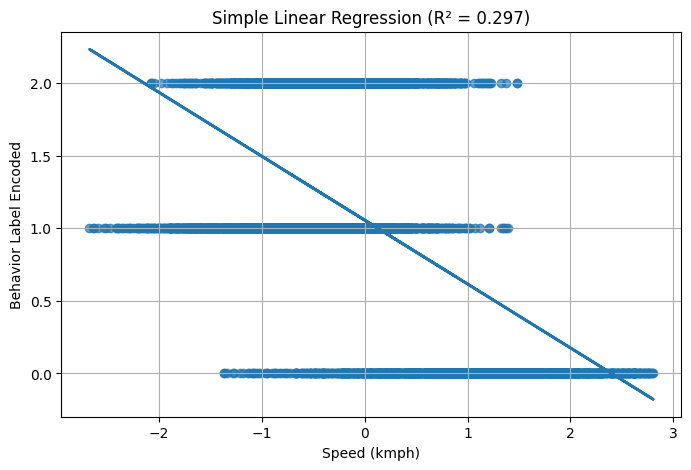

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, alpha=0.7)

plt.plot(X_test, y_pred, linewidth=2)

plt.xlabel("Speed (kmph)")

plt.ylabel("Behavior Label Encoded")

plt.title(f"Simple Linear Regression (R² = {r2:.3f})")

plt.grid(True)

plt.show()

In [24]:
with open('simple_linear_regression_model.pkl', 'wb') as file:
    pickle.dump(simple_model, file)

print("Simple Linear Regression model saved successfully as .pkl")

joblib.dump(simple_model, 'simple_linear_regression_model.joblib')

print("Simple Linear Regression model saved successfully as .joblib")

Simple Linear Regression model saved successfully as .pkl
Simple Linear Regression model saved successfully as .joblib
